# DIWAH — Machine Learning Evaluation Pipeline

This notebook demonstrates the exact pipeline used to calculate the MAE, RMSE, and $R^2$ metrics presented in the thesis dashboard. It clearly shows how the pooled dataset of 5-second FLIRT epochs is loaded, dynamically split using a strict 80/20 train/test partition, and evaluated.

In [14]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Loading and Pooling the Data
We load the master FLIRT feature matrix, which contains the 5-second epochs for all participants pooled together. The target variable is the Vyntus `mets`.

In [15]:
FEATURE_MATRIX_PATH = Path('Acc_pipe/data/processed/flirt_feature_matrix_ready.csv')

def load_and_prep_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Drop rows where 'mets' (target variable) is NaN
    df = df.dropna(subset=['mets'])
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce', utc=True)
    df = df.dropna(subset=['datetime'])
    return df

df = load_and_prep_data(FEATURE_MATRIX_PATH)
print(f"Total valid 5-second epochs loaded: {len(df)}")
y = df['mets'].values

Total valid 5-second epochs loaded: 115


## 2. Defining Device Scenarios
We define which columns belong to which device scenario based on prefix matching.

In [16]:
SCENARIOS = {
    "reference": {
        "label": "Reference (ActiGraph + Polar HR)",
        "prefixes": ["actigraph_", "hr_polar_stat_"]
    },
    "emotibit": {
        "label": "EmotiBit (Open-Source)",
        "prefixes": ["emotibit_"]
    },
    "bangle": {
        "label": "Bangle.js (Open-Source)",
        "prefixes": ["bangle_"]
    }
}

def get_scenario_columns(df: pd.DataFrame, prefixes: list) -> list:
    cols = []
    for prefix in prefixes:
        cols.extend([col for col in df.columns if col.startswith(prefix)])
    return cols

## 3. Training and Evaluation Pipeline (80/20 Split)
For each device scenario, we extract its features, perform a static 80/20 `train_test_split`, scale the data, and train the Ridge Regression and Random Forest models.

In [17]:
results = {}

for scenario_key, scenario_cfg in SCENARIOS.items():
    print(f"\n{'='*50}")
    print(f"Evaluating Scenario: {scenario_cfg['label']}")
    print(f"{'='*50}")
    
    features = get_scenario_columns(df, scenario_cfg["prefixes"])
    X = df[features]
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # 80/20 Train-Test Split (Pooled across all subjects)
    indices = np.arange(len(y))
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_imputed, y, indices, test_size=0.20, random_state=42
    )
    
    # Scale Features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Ridge Regression
    mlr = Ridge(alpha=1.0)
    mlr.fit(X_train_scaled, y_train)
    mlr_preds = mlr.predict(X_test_scaled)
    
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    rf_preds = rf.predict(X_test_scaled)
    
    # Calculate Metrics
    results[scenario_key] = {
        "Ridge": {
            "MAE": mean_absolute_error(y_test, mlr_preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, mlr_preds)),
            "R2": r2_score(y_test, mlr_preds)
        },
        "Random_Forest": {
            "MAE": mean_absolute_error(y_test, rf_preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
            "R2": r2_score(y_test, rf_preds)
        }
    }
    print("Random Forest Results:")
    print(f"  -> MAE:  {results[scenario_key]['Random_Forest']['MAE']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Random_Forest']['RMSE']:.3f} METs")
    print(f"  -> R²:   {results[scenario_key]['Random_Forest']['R2']:.3f}\n")
    print("Ridge Regression Results:")
    print(f"  -> MAE:  {results[scenario_key]['Ridge']['MAE']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Ridge']['RMSE']:.3f} METs")
    print(f"  -> R²:   {results[scenario_key]['Ridge']['R2']:.3f}\n")



Evaluating Scenario: Reference (ActiGraph + Polar HR)
Random Forest Results:
  -> MAE:  2.066 METs
  -> RMSE: 2.673 METs
  -> R²:   0.518

Ridge Regression Results:
  -> MAE:  2.916 METs
  -> RMSE: 3.802 METs
  -> R²:   0.025


Evaluating Scenario: EmotiBit (Open-Source)
Random Forest Results:
  -> MAE:  2.033 METs
  -> RMSE: 2.352 METs
  -> R²:   0.627

Ridge Regression Results:
  -> MAE:  2.448 METs
  -> RMSE: 3.265 METs
  -> R²:   0.282


Evaluating Scenario: Bangle.js (Open-Source)
Random Forest Results:
  -> MAE:  1.968 METs
  -> RMSE: 2.513 METs
  -> R²:   0.574

Ridge Regression Results:
  -> MAE:  3.140 METs
  -> RMSE: 5.399 METs
  -> R²:   -0.965



## 4. Visualizing the Results
Finally, we plot the Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and $R^2$ for both models across all devices so we can visually compare their performance.

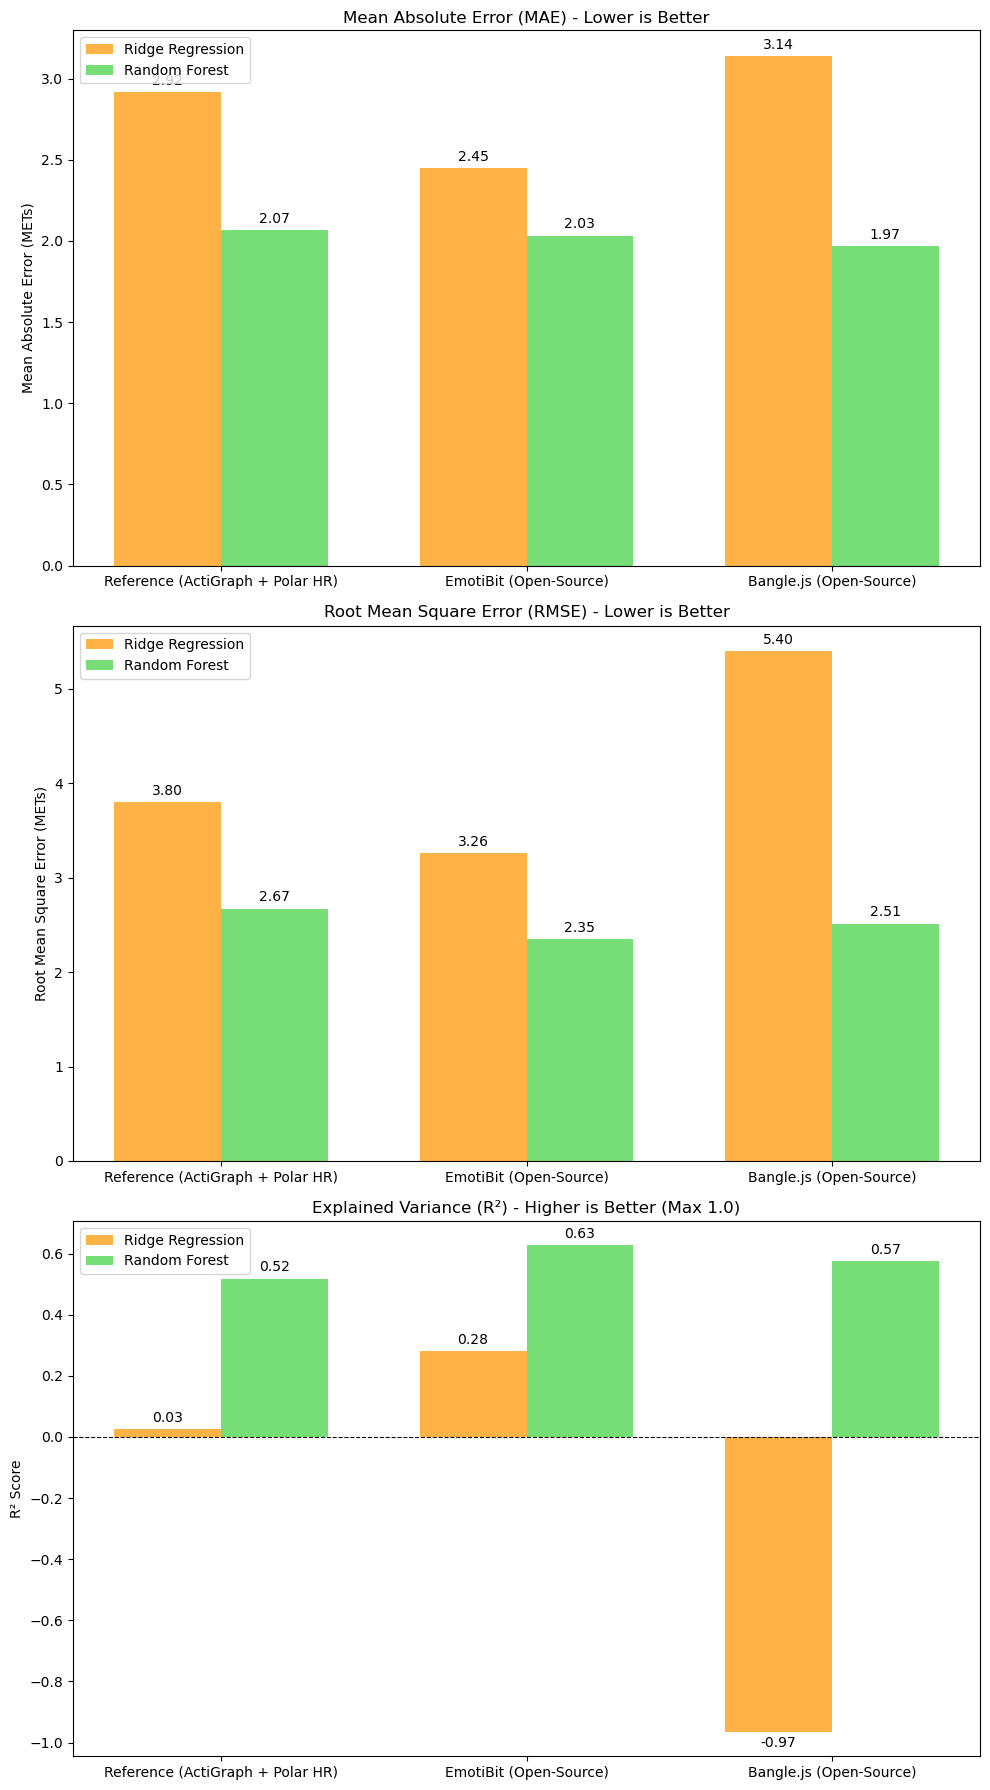

In [18]:
# Extract data for plotting
labels = [SCENARIOS[k]['label'] for k in results.keys()]

rf_maes = [results[k]['Random_Forest']['MAE'] for k in results.keys()]
ridge_maes = [results[k]['Ridge']['MAE'] for k in results.keys()]

rf_rmses = [results[k]['Random_Forest']['RMSE'] for k in results.keys()]
ridge_rmses = [results[k]['Ridge']['RMSE'] for k in results.keys()]

rf_r2 = [results[k]['Random_Forest']['R2'] for k in results.keys()]
ridge_r2 = [results[k]['Ridge']['R2'] for k in results.keys()]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# Create 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: MAE
rects1_mae = ax1.bar(x - width/2, ridge_maes, width, label='Ridge Regression', color='#FFB347')
rects2_mae = ax1.bar(x + width/2, rf_maes, width, label='Random Forest', color='#77DD77')
ax1.set_ylabel('Mean Absolute Error (METs)')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.bar_label(rects1_mae, padding=3, fmt='%.2f')
ax1.bar_label(rects2_mae, padding=3, fmt='%.2f')

# Plot 2: RMSE
rects1_rmse = ax2.bar(x - width/2, ridge_rmses, width, label='Ridge Regression', color='#FFB347')
rects2_rmse = ax2.bar(x + width/2, rf_rmses, width, label='Random Forest', color='#77DD77')
ax2.set_ylabel('Root Mean Square Error (METs)')
ax2.set_title('Root Mean Square Error (RMSE) - Lower is Better')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.bar_label(rects1_rmse, padding=3, fmt='%.2f')
ax2.bar_label(rects2_rmse, padding=3, fmt='%.2f')

# Plot 3: R2
rects1_r2 = ax3.bar(x - width/2, ridge_r2, width, label='Ridge Regression', color='#FFB347')
rects2_r2 = ax3.bar(x + width/2, rf_r2, width, label='Random Forest', color='#77DD77')
ax3.set_ylabel('R² Score')
ax3.set_title('Explained Variance (R²) - Higher is Better (Max 1.0)')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.legend()
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline 0 line
ax3.bar_label(rects1_r2, padding=3, fmt='%.2f')
ax3.bar_label(rects2_r2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()